# Multilayer Zigzag Persistent Homology:
## Jason LaRuez, Audun Myers, Brendan Rooney
In this notebook we apply multilayer zigzag persistence to a toy example where temporal-topological dynamics are present

In [ ]:
# Mounting to google drive. Forced remount allows you to access newly uploaded/updated files and
# folders in the googe drive. If files are stored locally or elsewhere, can comment out
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

import networkx as nx # Network structures
import numpy as np # Numpy arrays and operations
import random # Random sampling for network models
from itertools import combinations, product # For getting different simplices and all combinations of lists
import seaborn as sns # Displaying heatmaps

import matplotlib.pyplot as plt # Plotting
import matplotlib.animation as animation # Animating plots
import time # Timing simulations
from tqdm.notebook import trange, tqdm # Allows for real-time progress bar of simulations

import gc # Memory management
import pickle # Takes environment variables and saves them as is
import gzip # Allows for compression of saved files
from joblib import Parallel, delayed # Parallelization functions
import multiprocessing # Get number of cpu cores
import os # Iterating over directories for files
import math

# Installing packages not included in base google colab environment
!pip install dionysus==2.0.10 # Last version that is compatible with google colab
import dionysus as d # C++ package with python bindings for persistent homology

!pip install mne
import mne # Toolbox for EEG data

# Importing Multilayer_ZZPH.py
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks')
from Multilayer_ZZPH import * # Multilayer Zigzag Persistent Homology

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 17.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for dionysus: filename=dionysus-2.0.10-cp312-cp312-linux_x86_64.whl size=437482 sha256=2e72ae782cf093c80d6ea4342519bd0548630dd42816c275a14c3727553e6ced
  Stored in directory: /root/.cache/pip/wheels/11/9f/ca/ae26580795e766a8b6dce75ae4f29163b83b52d7a72efd5d48
Successfully built dionysus
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.0/167.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.8 MB/s eta 0:00:00


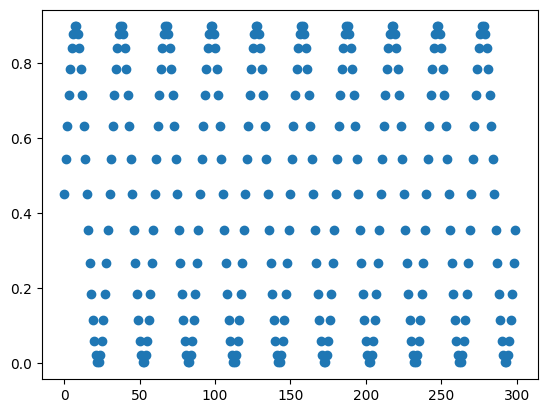

In [ ]:
period = 30; steps = list(range(period*10));
max_p_WS = 0.9
plt.scatter(steps, [0.5*(max_p_WS)*math.sin(2*np.pi * step / period) + 0.5*max_p_WS for step in steps])

In [ ]:
def RingWave(N, steps):
    """

    """
    #
    Edges = [set([tuple([i%N,(i+1)%N])]) for i in range(steps)]
    return Edges

def Windowing(width, layer, Edges):
    """
    Given a sequence of edge sets, form windowings of these edge
    sets where "width" is the initial width used in multilayer
    ZZPH, and layer (0, 1, ...) is the layer in the lattice for which
    the windowing is being constructed.
    """
    # The i-th window in any layer always contains the i-th window from the 0-layer
    W = [edges for i, edges in enumerate(Edges) if i < int(len(Edges)/width) - layer]

    # Take unions of neighboring windows based on the width and current layer
    for idx in range(int(len(Edges)/width) - layer):
        for j in range(1, layer+1):
            W[idx].update(Edges[idx+j])

    return W
# width = 1; layer = k means the window has length k+1
W = Windowing(1, 5, Edges)
dgms = ZZPH(W, width, layer)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

Calculating 1-distance for Period 20:   0%|          | 0/8 [00:00<?, ?it/s]

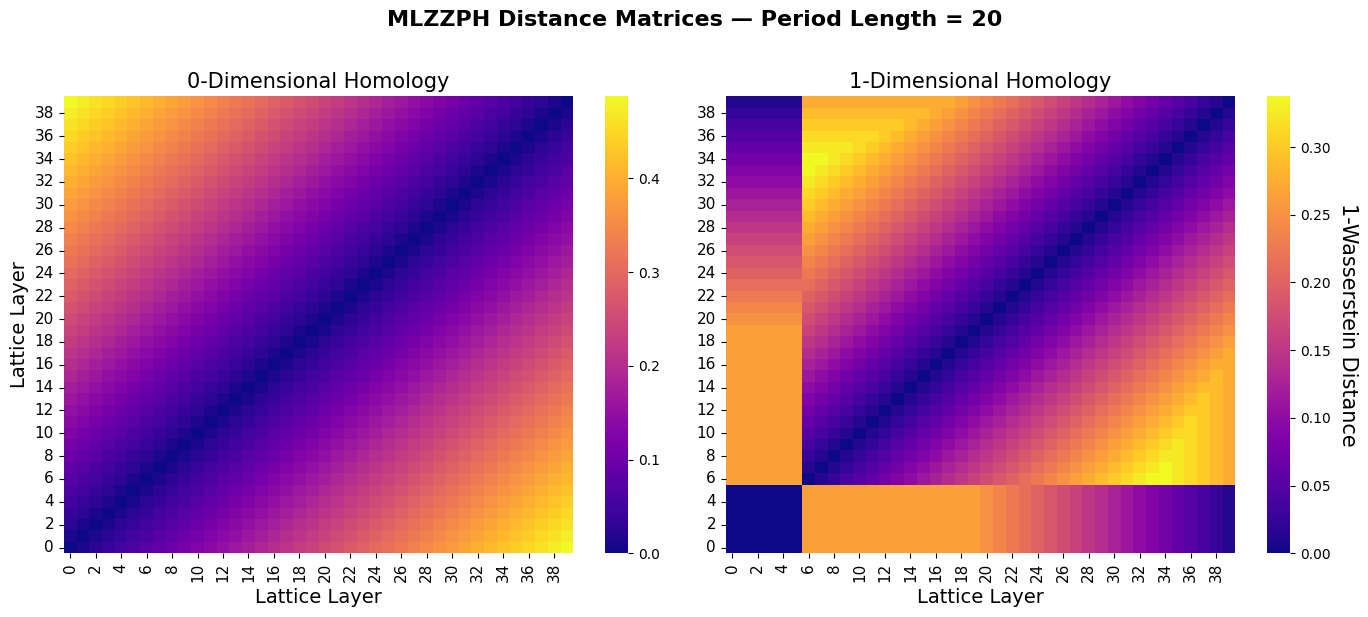

In [ ]:
N = [20]; DGMs = {}
width = 1;

for n in tqdm(N):
    length = 2*n
    Edges = RingWave(n, length)
    DGMs[n] = []
    layers = range(length)
    for layer in tqdm(layers):
        W = Windowing(width, layer, Edges)
        dgms = ZZPH(W, width, layer)
        DGMs[n].append(dgms)

    # Calculate 1-Wasserstein Distance
    d0, d1 = compute_distance_matrices(layers, n, DGMs, '1')

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))#, constrained_layout=True)
    fig.suptitle(f"MLZZPH Distance Matrices — Period Length = {n}",
             fontsize=16, fontweight="bold", y=1.02)
    sns.heatmap(d0, ax=ax[0], cmap="plasma")
    ax[0].set_title(f"0-Dimensional Homology",fontsize=15)
    ax[0].invert_yaxis()
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90, fontsize=11)
    ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=0, fontsize=11)
    ax[0].set_xlabel("Lattice Layer",fontsize=14)
    ax[0].set_ylabel("Lattice Layer",fontsize=14)

    sns.heatmap(d1, ax=ax[1], cmap="plasma",cbar_kws={"label": "1-Wasserstein Distance"})
    ax[1].set_title(f"1-Dimensional Homology",fontsize=15)
    ax[1].invert_yaxis()
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90, fontsize=11)
    ax[1].set_yticklabels(ax[0].get_yticklabels(), rotation=0, fontsize=11)
    ax[1].set_xlabel("Lattice Layer",fontsize=14)
    cbar = ax[1].collections[0].colorbar
    cbar.ax.set_ylabel("1-Wasserstein Distance", fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.show()

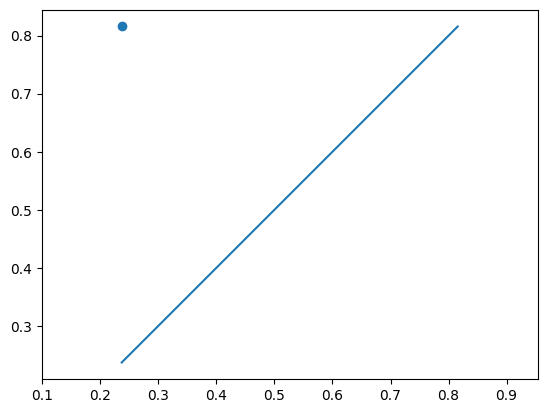

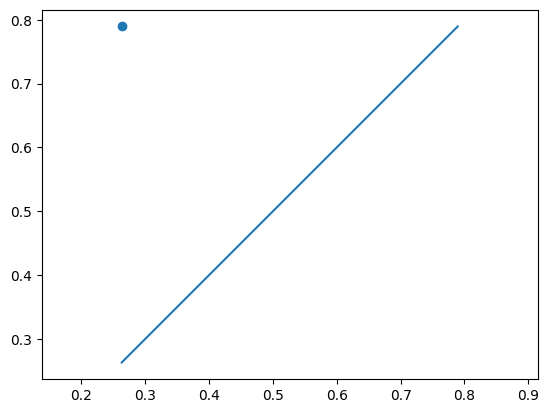

IndexError: list index out of range

In [ ]:
layer1 = 8; layer2 = 9; n = 20
d.plot.plot_diagram(DGMs[n][layer1][0], show = True)
d.plot.plot_diagram(DGMs[n][layer2][0], show = True)

d.plot.plot_diagram(DGMs[n][layer1][1], show = True)
d.plot.plot_diagram(DGMs[n][layer2][1], show = True)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

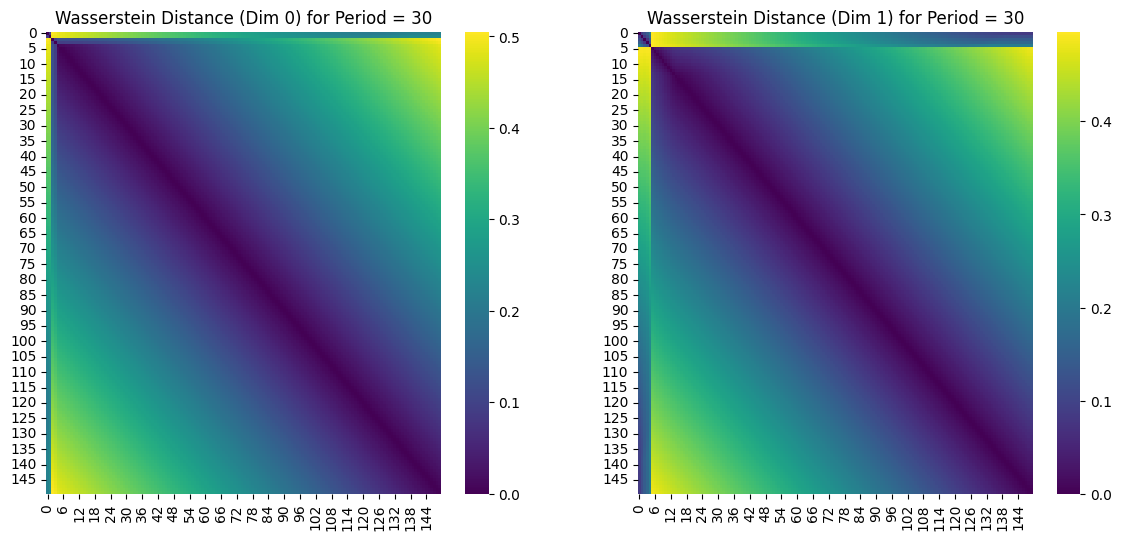

In [ ]:
N = 50; p_ER = 0; max_p_WS = 1; k_WS = 4; periods = [30]; #steps = 100
D0 = []; D1 = []; DGMs = {}
width = 1; #layers = range(1)
for period in tqdm(periods):
    Edges = PeriodicRing(N, p_ER, max_p_WS, k_WS, period, period * 5)
    DGMs[period] = []

    layers = range(5 * period)
    for layer in tqdm(layers):
        W = Windowing(width, layer, Edges)
        dgms = ZZPH(W, width, layer)
        DGMs[period].append(dgms)

    d0 = np.zeros((len(layers), len(layers)))
    d1 = np.zeros((len(layers), len(layers)))

    for i in tqdm(range(len(layers))):
        for j in range(i+1, len(layers)):
            d0[i,j] = d.wasserstein_distance(DGMs[period][i][0], DGMs[period][j][0], q=2)
            d0[j,i] = d0[i,j]
            d1[i,j] = d.wasserstein_distance(DGMs[period][i][1], DGMs[period][j][1], q=2)
            d1[j,i] = d1[i,j]
    D0.append(d0)
    D1.append(d1)

    # Mask infinite values for plotting purposes
    D0_plot = d0.copy()
    D0_plot[np.isinf(D0_plot)] = np.nan

    D1_plot = d1.copy()
    D1_plot[np.isinf(D1_plot)] = np.nan

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(D0_plot, ax=ax[0], cmap="viridis")
    ax[0].set_title(f"Wasserstein Distance (Dim 0) for Period = {period}")

    sns.heatmap(D1_plot, ax=ax[1], cmap="viridis")
    ax[1].set_title(f"Wasserstein Distance (Dim 1) for Period = {period}")

    plt.show()

In [ ]:
def remap(window_idx, width, layer, numWindows):
    return ( window_idx + (width / 2) * (layer + 1) ) / numWindows

def ZZPH(Edges, width, layer):
    """
    Given a sequence of edge sets, form a sequence of graphs,
    then for each graph construct the corresponding clique complex.
    Then, ZZPH is computed on this sequence of complexes and the
    resultant persistence diagrams are returned.
    """
    # Initialize T for times simplices are added and removed for ZZPH
    Times = dict()
    # Keep track of simplices from previous timestep to see track if
    # simplices remain or are removed in neighboring timesteps
    lastSimplices = set()

    for i, step_edges in enumerate(Edges):
        Simplices = set()

        # For graph from edge set and find maximal cliques
        G = nx.Graph()
        G.add_edges_from(step_edges)
        cliques = list(nx.find_cliques(G))

        # Iterate over maximal cliques to enumerate all simplices (dim 3 or less) which
        # are present in the current windowed graph
        for clique in cliques:
            numNodes = len(clique)
            clique = sorted(clique)
            for r in range(1, min(numNodes, 4)+1):
                # combinations(S,r) is from itertools and returns iterator corresponding
                # to all r-subsets of S.
                for face in combinations(clique, r):
                    if face not in Simplices:
                        Simplices.add(face)
                        # In this case the face had previously been added and removed, so we add it again
                        if (face in Times) and (face not in lastSimplices):
                            Times[face].append(i)#(i-(4-len(face)) / 100)
                        # In this case the face had never existed, so we add it for the first time
                        elif face not in Times:
                            Times[face] = [i]#[i-(4-len(face)) / 100]

        # Checking if simplices from prior timestep persisted
        for simplex in lastSimplices:
            # The simplex existed in prior timestep but not in current, so
            # it exists in T. We append removal time to T. Otherwise, the simplex
            # is still present in the current timestep so we do not update T yet
            if simplex not in Simplices:
                Times[simplex].append(i)#(i + (4-len(simplex)) / 100)

        # Update prior simplices to current timestep
        lastSimplices = Simplices.copy()

    # Remove all simplices at the end to avoid infinitely persistent features
    for simplex in lastSimplices:
        Times[simplex].append(len(Edges))

    # Extract list of every simplex added/removed, and list of times they were
    # added/removed, for input into zigzag persistence.
    simplices = [list(key) for key in Times]; times = [[remap(Times[key][i],width,layer,len(Edges)+layer) for i in range(len(Times[key]))] for key in Times]
    #return simplices, times
    # Construct filtration and compute homology
    f = d.Filtration(simplices)
    zz, dgms, cells = d.zigzag_homology_persistence(f, times)

    return dgms

In [ ]:
def compute_distance_matrices(layers, period, DGMs, p):
    """
    Computes D0 and D1 Wasserstein or Bottleneck distance matrices
    between persistence diagrams for given layers and period.

    Parameters:
    - layers: A range or list of layer indices.
    - period: The current period being processed (used to access DGMs).
    - DGMs: Dictionary containing persistence diagrams (DGMs[period][layer][dim]).
    - p: String indicating the distance type ('1' for 1-Wasserstein, '2' for 2-Wasserstein, 'inf' for Bottleneck).

    Returns:
    - d0: The computed distance matrix for dimension 0.
    - d1: The computed distance matrix for dimension 1.
    """
    n_layers = len(layers)
    d0 = np.zeros((n_layers, n_layers))
    d1 = np.zeros((n_layers, n_layers))

    def calculate_distances_for_chunk(chunk, period_data, p_type):
        """Process a list of (i,j) pairs, returning a list of (i,j,dist0,dist1)."""
        results = []
        for i, j in chunk:
            dgm_i_0 = period_data[i][0]
            dgm_j_0 = period_data[j][0]
            dgm_i_1 = period_data[i][1] if len(period_data[i]) > 1 else d.Diagram()
            dgm_j_1 = period_data[j][1] if len(period_data[j]) > 1 else d.Diagram()

            dist0, dist1 = 0.0, 0.0
            if p_type == '1':
                dist0 = d.wasserstein_distance(dgm_i_0, dgm_j_0, q=1, internal_p=-1)
                dist1 = d.wasserstein_distance(dgm_i_1, dgm_j_1, q=1, internal_p=-1)
            elif p_type == '2':
                dist0 = d.wasserstein_distance(dgm_i_0, dgm_j_0, q=2, internal_p=-2)
                dist1 = d.wasserstein_distance(dgm_i_1, dgm_j_1, q=2, internal_p=-2)
            elif p_type == 'inf':
                dist0 = d.bottleneck_distance(dgm_i_0, dgm_j_0)
                dist1 = d.bottleneck_distance(dgm_i_1, dgm_j_1)
            else:
                raise ValueError("Invalid value for 'p'. Must be '1', '2', or 'inf'.")
            results.append((i, j, dist0, dist1))
        return results

    # Generate all unique (i, j) pairs for upper triangle
    pairs = [(i, j) for i in range(n_layers) for j in range(i + 1, n_layers)]

    # Split pairs into one chunk per worker
    n_jobs = multiprocessing.cpu_count()
    chunks = [pairs[k::n_jobs] for k in range(n_jobs)]

    # Each worker receives a whole chunk to loop through internally
    results_nested = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(calculate_distances_for_chunk)(chunk, DGMs[period], p)
        for chunk in tqdm(chunks, desc=f"Calculating {p}-distance for Period {period}")
    )

    # Flatten results and populate distance matrices
    for chunk_results in results_nested:
        for i, j, dist0, dist1 in chunk_results:
            d0[i, j] = dist0; d0[j, i] = dist0
            d1[i, j] = dist1; d1[j, i] = dist1

    return d0, d1

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

Calculating 1-distance for Period 20:   0%|          | 0/8 [00:00<?, ?it/s]

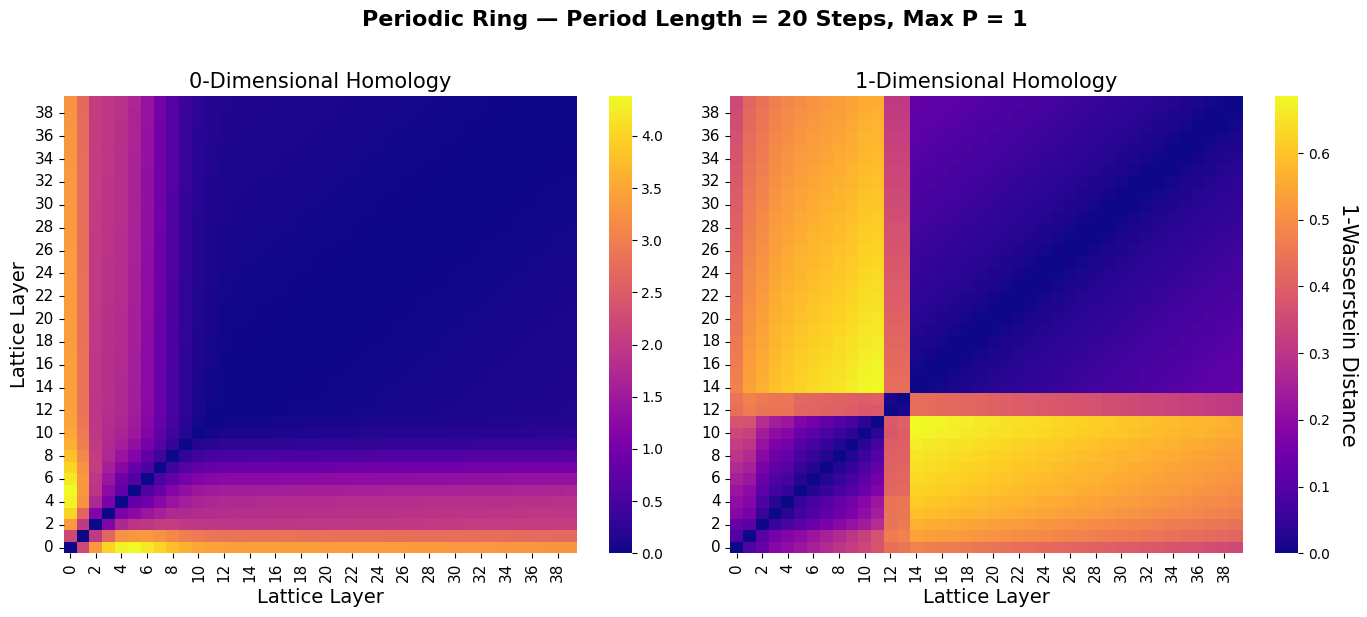

  0%|          | 0/60 [00:00<?, ?it/s]

Calculating 1-distance for Period 30:   0%|          | 0/8 [00:00<?, ?it/s]

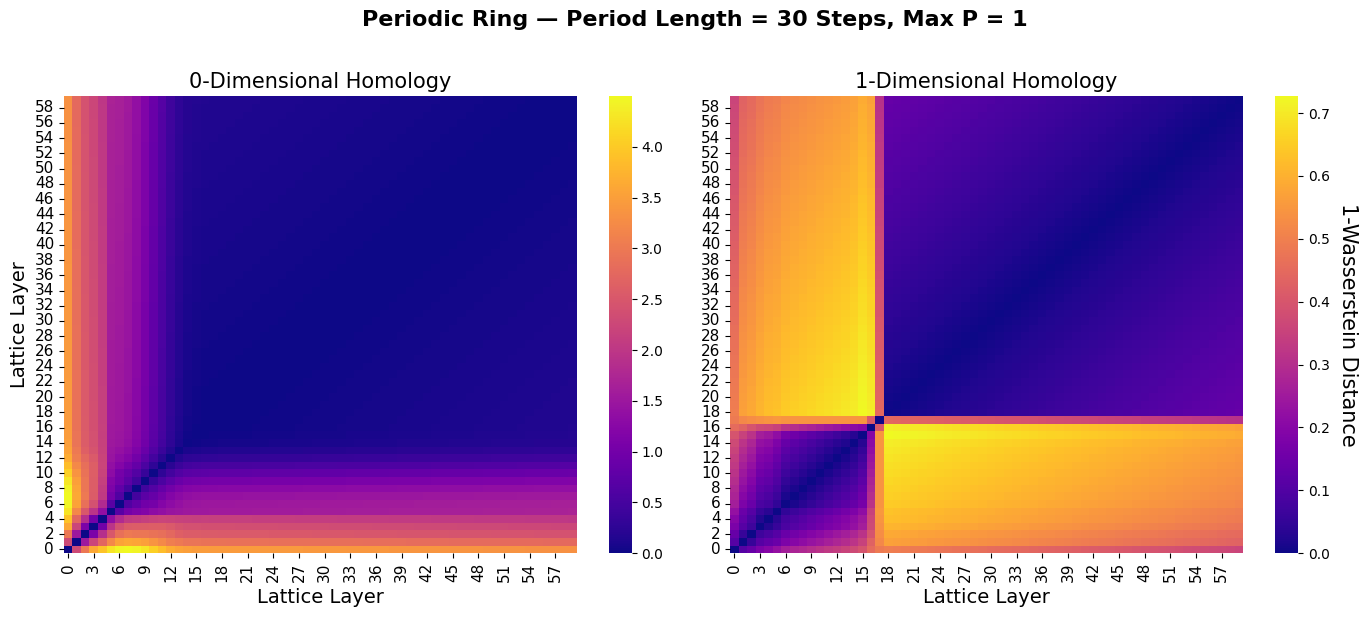

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 40:   0%|          | 0/8 [00:00<?, ?it/s]

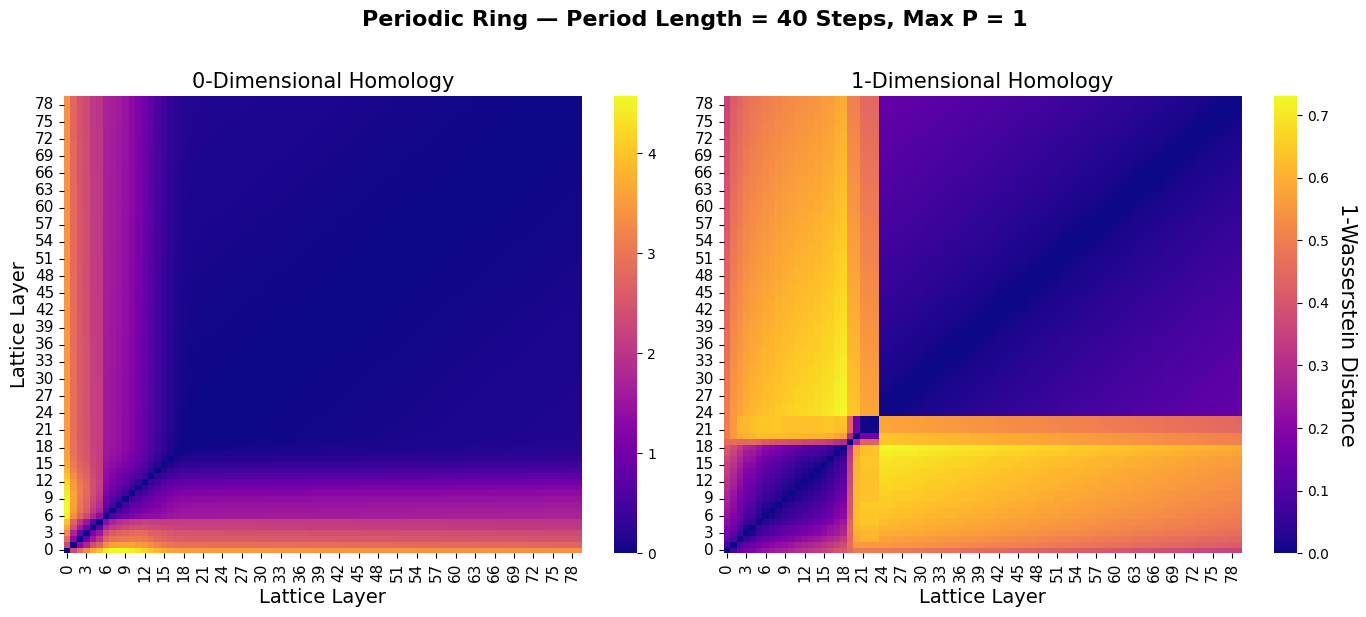

In [ ]:
N = 50; p_ER = 0; max_p_WS = 1; k_WS = 2; periods = [20,30,40]; #steps = 100
D0 = {period: dict() for period in periods}; D1 = {period: dict() for period in periods}; DGMs = {}
width = 1;

for period in tqdm(periods):
    length = 5 * period
    Edges = PeriodicRing(N, p_ER, max_p_WS, k_WS, period, length)
    DGMs[period] = []
    layers = range(2 * period)
    for layer in tqdm(layers):
        W = Windowing(width, layer, Edges)
        dgms = ZZPH(W, width, layer)
        DGMs[period].append(dgms)

    # Calculate 1-Wasserstein Distance
    d0, d1 = compute_distance_matrices(layers, period, DGMs, '1')
    D0[period]['1'] = d0
    D1[period]['1'] = d1

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))#, constrained_layout=True)
    fig.suptitle(f"Periodic Ring — Period Length = {period} Steps, Max P = {max_p_WS}",
             fontsize=16, fontweight="bold", y=1.02)
    sns.heatmap(d0, ax=ax[0], cmap="plasma")
    ax[0].set_title(f"0-Dimensional Homology",fontsize=15)
    ax[0].invert_yaxis()
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90, fontsize=11)
    ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=0, fontsize=11)
    ax[0].set_xlabel("Lattice Layer",fontsize=14)
    ax[0].set_ylabel("Lattice Layer",fontsize=14)

    sns.heatmap(d1, ax=ax[1], cmap="plasma",cbar_kws={"label": "1-Wasserstein Distance"})
    ax[1].set_title(f"1-Dimensional Homology",fontsize=15)
    ax[1].invert_yaxis()
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90, fontsize=11)
    ax[1].set_yticklabels(ax[0].get_yticklabels(), rotation=0, fontsize=11)
    ax[1].set_xlabel("Lattice Layer",fontsize=14)
    cbar = ax[1].collections[0].colorbar
    cbar.ax.set_ylabel("1-Wasserstein Distance", fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def plot_period_group_publication(period_group, D0, D1, p_max_WS, figsize=(10, 13)):
    nrows = len(period_group)

    # Collect matrices so each homology column uses a fixed shared color scale
    all_d0 = [np.asarray(D0[p]['1']) for p in period_group]
    all_d1 = [np.asarray(D1[p]['1']) for p in period_group]

    vmin0 = min(arr.min() for arr in all_d0)
    vmax0 = max(arr.max() for arr in all_d0)
    vmin1 = min(arr.min() for arr in all_d1)
    vmax1 = max(arr.max() for arr in all_d1)

    # Figure + axes
    fig, ax = plt.subplots(
        nrows, 2,
        figsize=figsize,
        constrained_layout=False,
        gridspec_kw={"wspace": 0.18, "hspace": 0.18}
    )

    if nrows == 1:
        ax = np.array([ax])

    # Supertitle
    fig.suptitle(
        f"Ring Model: $p_{{\\max}}$ = {p_max_WS}",
        fontsize=16,
        fontweight="bold",
        y=0.93
    )

    for i, period in enumerate(period_group):
        d0 = np.asarray(D0[period]['1'])
        d1 = np.asarray(D1[period]['1'])

        n0 = d0.shape[0]
        n1 = d1.shape[0]

        # Choose readable tick spacing automatically
        step0 = max(1, int(np.ceil(n0 / 10)))
        step1 = max(1, int(np.ceil(n1 / 10)))

        ticks0 = np.arange(0, n0, step0)
        ticks1 = np.arange(0, n1, step1)

        # ----- Left column: 0-dimensional homology -----
        hm0 = sns.heatmap(
            d0,
            ax=ax[i, 0],
            cmap="plasma",
            vmin=vmin0,
            vmax=vmax0,
            cbar=True,
            cbar_kws={"shrink": 1.0}
        )
        ax[i, 0].invert_yaxis()

        if i == 0:
            ax[i, 0].set_title("0-Dimensional Homology", fontsize=14, pad=6)

        if i == nrows - 1:
            ax[i, 0].set_xlabel("Lattice Layer", fontsize=12)
        else:
            ax[i, 0].set_xlabel("")

        ax[i, 0].set_ylabel("Lattice Layer", fontsize=12)

        ax[i, 0].set_xticks(ticks0 + 0.5)
        ax[i, 0].set_xticklabels(ticks0, rotation=90, fontsize=9)
        ax[i, 0].set_yticks(ticks0 + 0.5)
        ax[i, 0].set_yticklabels(ticks0, rotation=0, fontsize=9)

        # Remove label from left colorbar
        cbar0 = hm0.collections[0].colorbar
        cbar0.ax.set_ylabel("")
        cbar0.ax.tick_params(labelsize=10)

        # Horizontal period label with gray box behind it
        ax[i, 0].text(
            -0.25, 0.5,
            f"Period = {period}",
            transform=ax[i, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=12,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="lightgray",
                edgecolor="gray",
                alpha=1.0
            )
        )

        # ----- Right column: 1-dimensional homology -----
        hm1 = sns.heatmap(
            d1,
            ax=ax[i, 1],
            cmap="plasma",
            vmin=vmin1,
            vmax=vmax1,
            cbar=True,
            cbar_kws={"label": "1-Wasserstein Distance", "shrink": 1.0}
        )
        ax[i, 1].invert_yaxis()

        if i == 0:
            ax[i, 1].set_title("1-Dimensional Homology", fontsize=14, pad=6)

        if i == nrows - 1:
            ax[i, 1].set_xlabel("Lattice Layer", fontsize=12)
        else:
            ax[i, 1].set_xlabel("")

        ax[i, 1].set_ylabel("")

        ax[i, 1].set_xticks(ticks1 + 0.5)
        ax[i, 1].set_xticklabels(ticks1, rotation=90, fontsize=9)
        ax[i, 1].set_yticks(ticks1 + 0.5)
        ax[i, 1].set_yticklabels(ticks1, rotation=0, fontsize=9)

        cbar1 = hm1.collections[0].colorbar
        cbar1.ax.set_ylabel("1-Wasserstein Distance", fontsize=12, rotation=270, labelpad=16)
        cbar1.ax.tick_params(labelsize=10)

    plt.tight_layout(rect=[0.10, 0.04, 0.98, 0.91])
    plt.show()


# Figure 1: periods 20, 25, 30
#plot_period_group_publication([20, 30, 40], D0, D1, p_max_WS, figsize=(10, 13))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import dionysus as d


def plot_persistence_diagram_publication(
    diagram,
    ax=None,
    title=None,
    point_size=42,
    point_color="#123B6D",   # dark blue
    diag_color="0.55",
    tick_fontsize=11,
    label_fontsize=13,
    title_fontsize=14
):
    """
    Plot a Dionysus persistence diagram in a publication-style format.

    Parameters
    ----------
    diagram : dionysus diagram
        A persistence diagram, e.g. DGMs[period][layer][dim]
    ax : matplotlib.axes.Axes or None
        Axis to draw on. If None, creates a new figure.
    title : str or None
        Optional subplot title.
    point_size : float
        Scatter marker size.
    point_color : str
        Color of persistence points.
    diag_color : str
        Color of diagonal y=x line.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 5.5))

    births = []
    deaths = []

    # Extract finite points only
    for pt in diagram:
        b = float(pt.birth)
        de = float(pt.death)

        if np.isfinite(b) and np.isfinite(de):
            births.append(b)
            deaths.append(de)

    births = np.array(births)
    deaths = np.array(deaths)

    # Scatter points
    if len(births) > 0:
        ax.scatter(
            births,
            deaths,
            s=point_size,
            color=point_color,
            edgecolors="black",
            linewidths=0.35,
            zorder=3
        )

    # Diagonal reference line
    ax.plot([0, 1], [0, 1], linestyle="-", linewidth=1.4, color=diag_color, zorder=1)

    # Fixed axes requested
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Labels
    ax.set_xlabel("Normalized Birth Time", fontsize=label_fontsize)
    ax.set_ylabel("Normalized Death Time", fontsize=label_fontsize)

    # Optional title
    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, pad=8)

    # Clean styling
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.set_aspect("equal", adjustable="box")

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    return ax

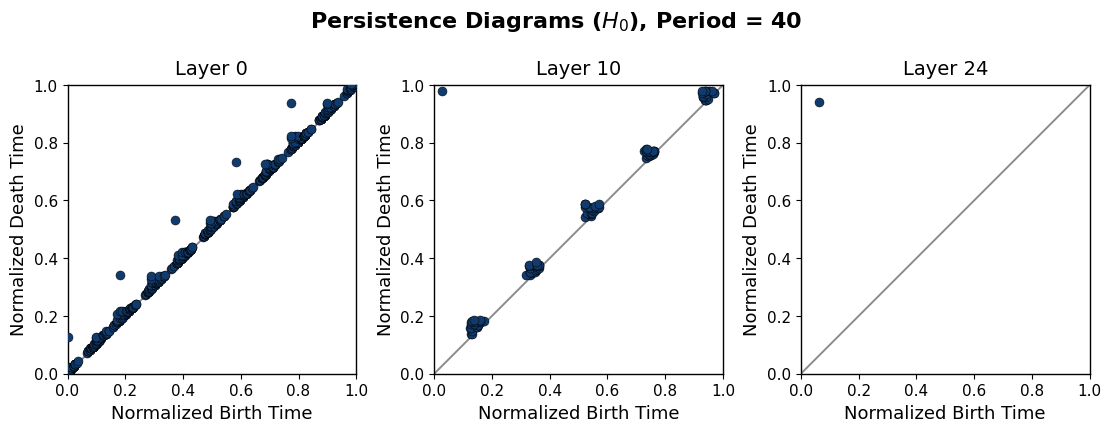

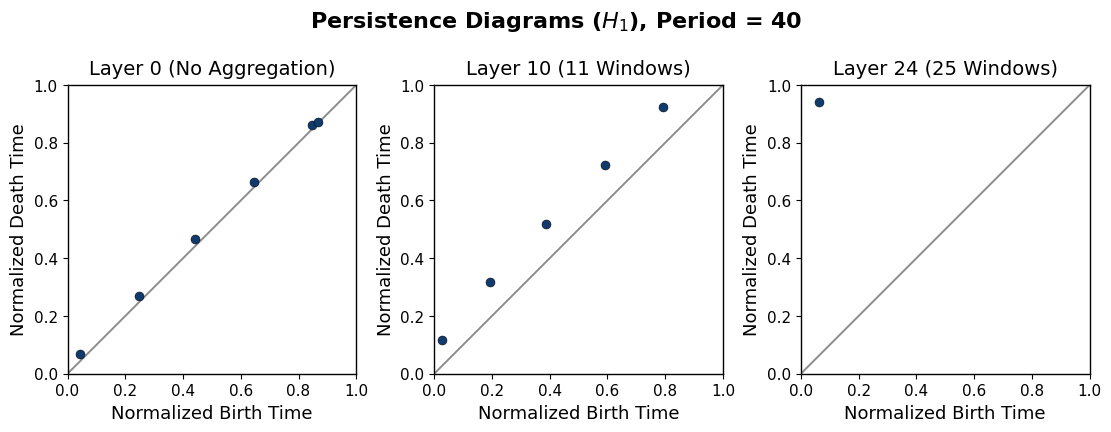

In [ ]:
# Example usage for your four diagrams
layer1 = 0
layer2 = 10
layer3 = 24
period = 40

# ---- H0 figure ----
fig, ax = plt.subplots(1, 3, figsize=(11, 5.5), constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[period][layer1][0],
    ax=ax[0],
    title=f"Layer {layer1}"
)

plot_persistence_diagram_publication(
    DGMs[period][layer2][0],
    ax=ax[1],
    title=f"Layer {layer2}"
)

plot_persistence_diagram_publication(
    DGMs[period][layer3][0],
    ax=ax[2],
    title=f"Layer {layer3}"
)

fig.suptitle(f"Persistence Diagrams ($H_0$), Period = {period}", fontsize=16, fontweight="bold", y = 0.9)
plt.show()


# ---- H1 figure ----
fig, ax = plt.subplots(1, 3, figsize=(11, 5.5), constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[period][layer1][1],
    ax=ax[0],
    title=f"Layer {layer1} (No Aggregation)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer2][1],
    ax=ax[1],
    title=f"Layer {layer2} ({layer2+1} Windows)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer3][1],
    ax=ax[2],
    title=f"Layer {layer3} ({layer3+1} Windows)"
)

fig.suptitle(f"Persistence Diagrams ($H_1$), Period = {period}", fontsize=16, fontweight="bold", y = 0.9)
plt.show()

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 0.8:   0%|          | 0/8 [00:00<?, ?it/s]

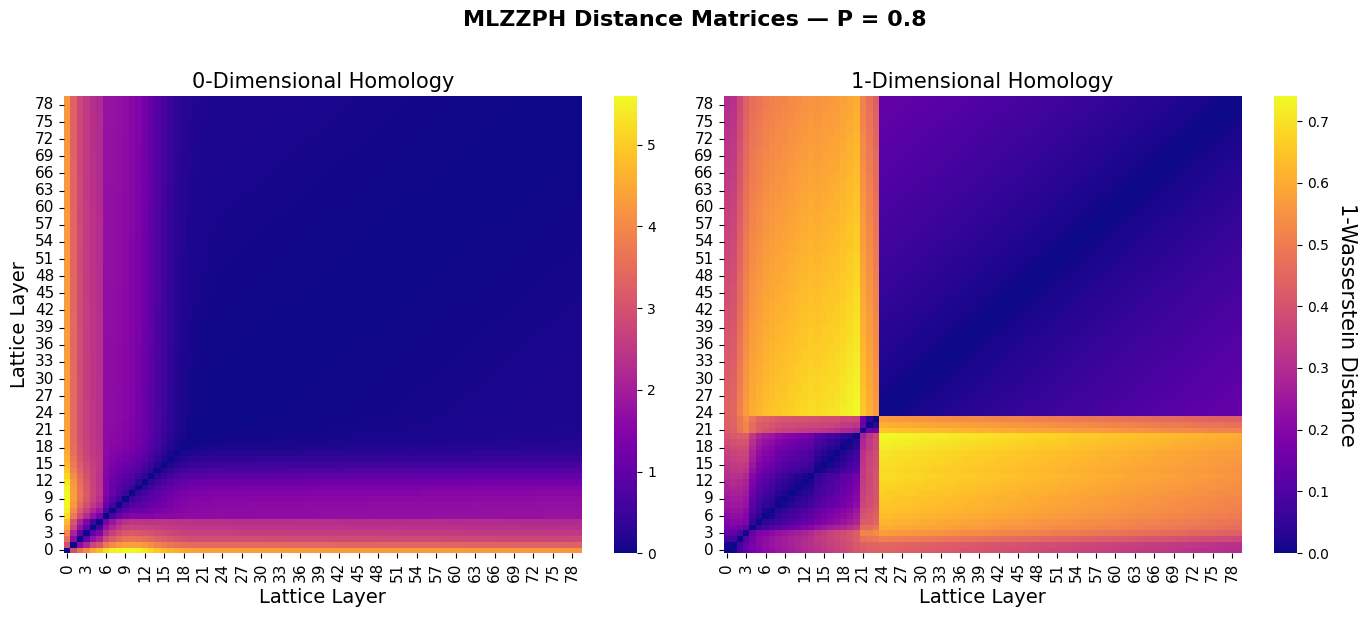

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 1:   0%|          | 0/8 [00:00<?, ?it/s]

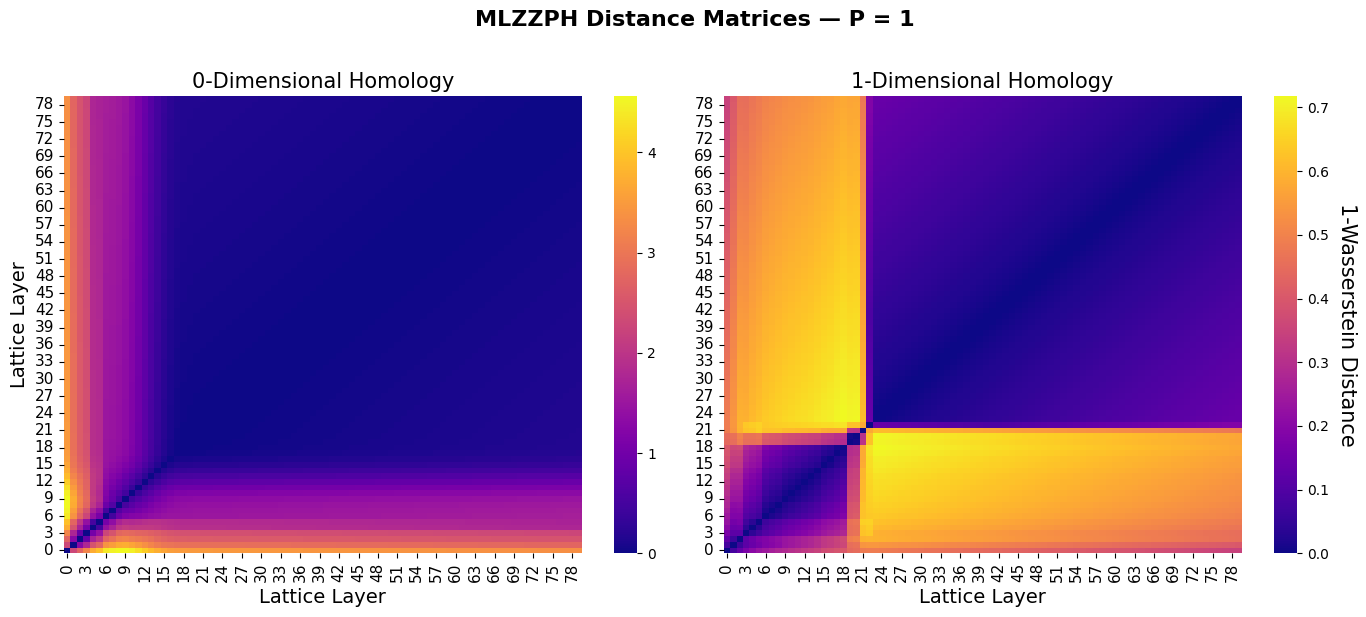

In [ ]:
N = 50; p_ER = 0; max_P = [0.8,1]; k_WS = 2; period = 40;
D0 = {p: dict() for p in max_P}; D1 = {p: dict() for p in max_P}; DGMs = {}
width = 1;

for p in tqdm(max_P):
    length = 5 * period
    Edges = PeriodicRing(N, p_ER, p, k_WS, period, length)
    DGMs[p] = []
    layers = range(2 * period)
    for layer in tqdm(layers):
        W = Windowing(width, layer, Edges)
        dgms = ZZPH(W, width, layer)
        DGMs[p].append(dgms)

    # Calculate 1-Wasserstein Distance
    d0, d1 = compute_distance_matrices(layers, p, DGMs, '1')
    D0[p]['1'] = d0
    D1[p]['1'] = d1

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))#, constrained_layout=True)
    fig.suptitle(f"MLZZPH Distance Matrices — P = {p}",
             fontsize=16, fontweight="bold", y=1.02)
    sns.heatmap(d0, ax=ax[0], cmap="plasma")
    ax[0].set_title(f"0-Dimensional Homology",fontsize=15)
    ax[0].invert_yaxis()
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90, fontsize=11)
    ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=0, fontsize=11)
    ax[0].set_xlabel("Lattice Layer",fontsize=14)
    ax[0].set_ylabel("Lattice Layer",fontsize=14)

    sns.heatmap(d1, ax=ax[1], cmap="plasma",cbar_kws={"label": "1-Wasserstein Distance"})
    ax[1].set_title(f"1-Dimensional Homology",fontsize=15)
    ax[1].invert_yaxis()
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90, fontsize=11)
    ax[1].set_yticklabels(ax[0].get_yticklabels(), rotation=0, fontsize=11)
    ax[1].set_xlabel("Lattice Layer",fontsize=14)
    cbar = ax[1].collections[0].colorbar
    cbar.ax.set_ylabel("1-Wasserstein Distance", fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.show()

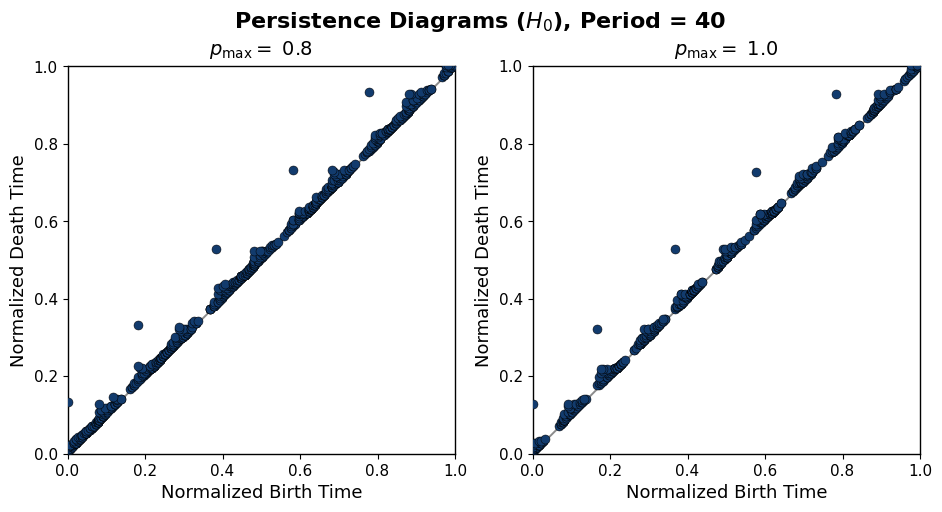

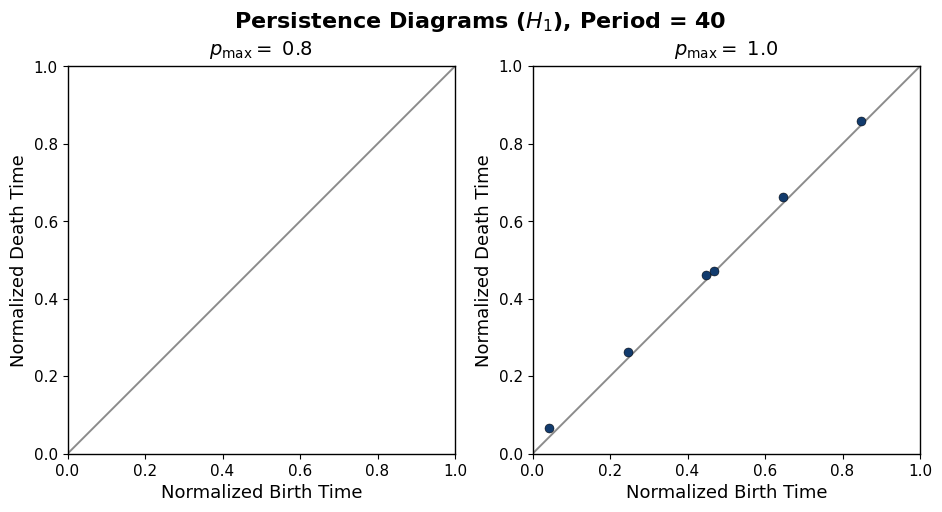

In [ ]:
# Example usage for your four diagrams
layer1 = 0
layer2 = 0
p_1 = 0.8
p_2 = 1.0

# ---- H0 figure ----
fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))#, constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[p_1][layer1][0],
    ax=ax[0],
    title=f"$p_{{\\max}} = $ {p_1}"
)

plot_persistence_diagram_publication(
    DGMs[p_2][layer2][0],
    ax=ax[1],
    title=f"$p_{{\\max}} = $ {p_2}"
)

fig.suptitle(f"Persistence Diagrams ($H_0$), Period = {period}", fontsize=16, fontweight="bold", y = 0.95)
plt.show()


# ---- H1 figure ----
fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))#, constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[p_1][layer1][1] if len(DGMs[p_1][layer2]) > 1 else d.Diagram(),
    ax=ax[0],
    title=f"$p_{{\\max}} = $ {p_1}"
)

plot_persistence_diagram_publication(
    DGMs[p_2][layer2][1] if len(DGMs[p_2][layer2]) > 1 else d.Diagram(),
    ax=ax[1],
    title=f"$p_{{\\max}} = $ {p_2}"
)

fig.suptitle(f"Persistence Diagrams ($H_1$), Period = {period}", fontsize=16, fontweight="bold", y = 0.95)
plt.show()

In [ ]:
def plot_period_group_publication_pmax(p_group, D0, D1, period, figsize=(10, 13)):
    nrows = len(p_group)

    # Collect matrices so each homology column uses a fixed shared color scale
    all_d0 = [np.asarray(D0[p]['1']) for p in p_group]
    all_d1 = [np.asarray(D1[p]['1']) for p in p_group]

    vmin0 = min(arr.min() for arr in all_d0)
    vmax0 = max(arr.max() for arr in all_d0)
    vmin1 = min(arr.min() for arr in all_d1)
    vmax1 = max(arr.max() for arr in all_d1)

    # Figure + axes
    fig, ax = plt.subplots(
        nrows, 2,
        figsize=figsize,
        constrained_layout=False,
        gridspec_kw={"wspace": 0.18, "hspace": 0.18}
    )

    if nrows == 1:
        ax = np.array([ax])

    # Supertitle
    fig.suptitle(
        f"Ring Model: Period = {period}",
        fontsize=16,
        fontweight="bold",
        y=0.93
    )

    for i, p in enumerate(p_group):
        d0 = np.asarray(D0[p]['1'])
        d1 = np.asarray(D1[p]['1'])

        n0 = d0.shape[0]
        n1 = d1.shape[0]

        # Choose readable tick spacing automatically
        step0 = max(1, int(np.ceil(n0 / 10)))
        step1 = max(1, int(np.ceil(n1 / 10)))

        ticks0 = np.arange(0, n0, step0)
        ticks1 = np.arange(0, n1, step1)

        # ----- Left column: 0-dimensional homology -----
        hm0 = sns.heatmap(
            d0,
            ax=ax[i, 0],
            cmap="plasma",
            vmin=vmin0,
            vmax=vmax0,
            cbar=True,
            cbar_kws={"shrink": 1.0}
        )
        ax[i, 0].invert_yaxis()

        if i == 0:
            ax[i, 0].set_title("0-Dimensional Homology", fontsize=14, pad=6)

        if i == nrows - 1:
            ax[i, 0].set_xlabel("Lattice Layer", fontsize=12)
        else:
            ax[i, 0].set_xlabel("")

        ax[i, 0].set_ylabel("Lattice Layer", fontsize=12)

        ax[i, 0].set_xticks(ticks0 + 0.5)
        ax[i, 0].set_xticklabels(ticks0, rotation=90, fontsize=9)
        ax[i, 0].set_yticks(ticks0 + 0.5)
        ax[i, 0].set_yticklabels(ticks0, rotation=0, fontsize=9)

        # Remove label from left colorbar
        cbar0 = hm0.collections[0].colorbar
        cbar0.ax.set_ylabel("")
        cbar0.ax.tick_params(labelsize=10)

        # Horizontal period label with gray box behind it
        ax[i, 0].text(
            -0.25, 0.5,
            f"$p_{{\\max}}$ = {p}",
            transform=ax[i, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=12,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="lightgray",
                edgecolor="gray",
                alpha=1.0
            )
        )

        # ----- Right column: 1-dimensional homology -----
        hm1 = sns.heatmap(
            d1,
            ax=ax[i, 1],
            cmap="plasma",
            vmin=vmin1,
            vmax=vmax1,
            cbar=True,
            cbar_kws={"label": "1-Wasserstein Distance", "shrink": 1.0}
        )
        ax[i, 1].invert_yaxis()

        if i == 0:
            ax[i, 1].set_title("1-Dimensional Homology", fontsize=14, pad=6)

        if i == nrows - 1:
            ax[i, 1].set_xlabel("Lattice Layer", fontsize=12)
        else:
            ax[i, 1].set_xlabel("")

        ax[i, 1].set_ylabel("")

        ax[i, 1].set_xticks(ticks1 + 0.5)
        ax[i, 1].set_xticklabels(ticks1, rotation=90, fontsize=9)
        ax[i, 1].set_yticks(ticks1 + 0.5)
        ax[i, 1].set_yticklabels(ticks1, rotation=0, fontsize=9)

        cbar1 = hm1.collections[0].colorbar
        cbar1.ax.set_ylabel("1-Wasserstein Distance", fontsize=12, rotation=270, labelpad=16)
        cbar1.ax.tick_params(labelsize=10)

    plt.tight_layout(rect=[0.10, 0.04, 0.98, 0.91])
    plt.show()

/tmp/ipykernel_15283/1265917489.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.10, 0.04, 0.98, 0.91])


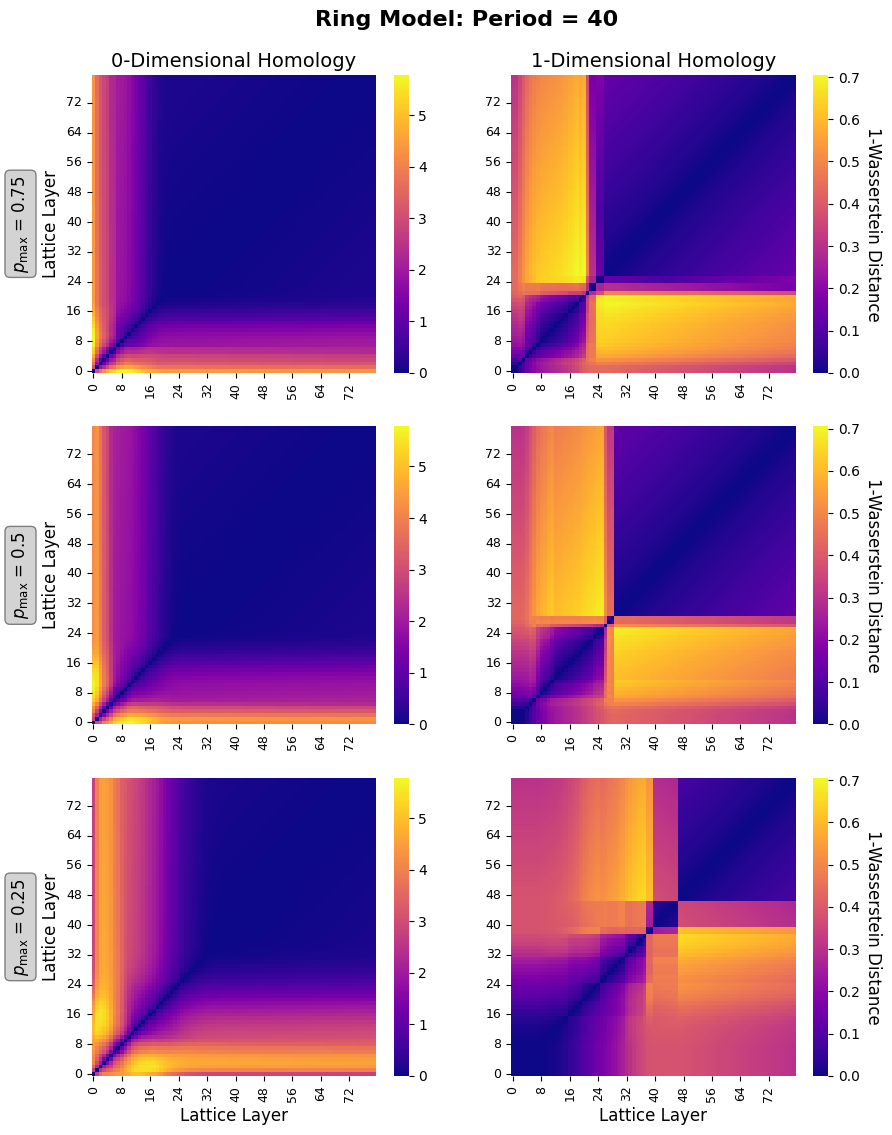

In [ ]:
# Figure 1: periods 20, 25, 30
plot_period_group_publication_pmax([0.75,0.5,0.25], D0, D1, 40, figsize=(10, 13))

# Figure 2: periods 35, 40, 45
#plot_period_group_publication([35, 40, 45], D0, D1, max_p_WS, figsize=(10, 13))

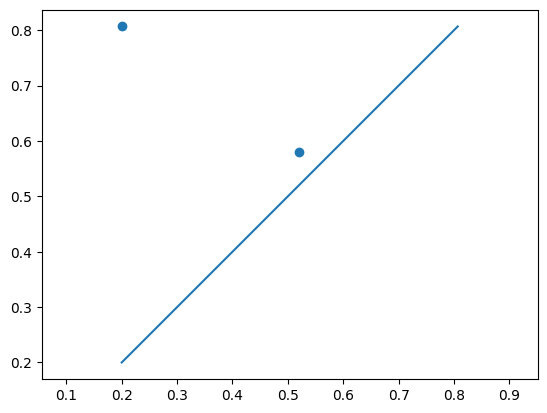

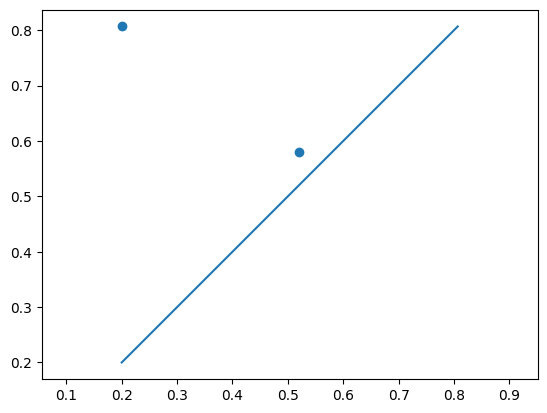

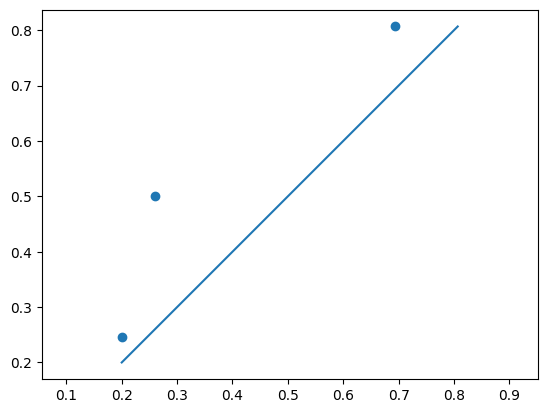

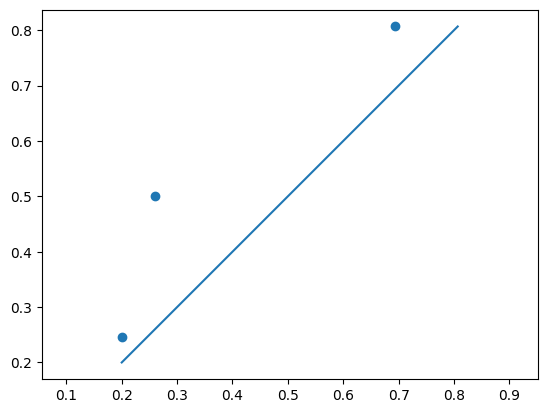

In [ ]:
layer1 = -1; layer2 = -1; period = 30
d.plot.plot_diagram(DGMs[period][layer1][0], show = True)
d.plot.plot_diagram(DGMs[period][layer2][0], show = True)

d.plot.plot_diagram(DGMs[period][layer1][1], show = True)
d.plot.plot_diagram(DGMs[period][layer2][1], show = True)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 0.001:   0%|          | 0/8 [00:00<?, ?it/s]

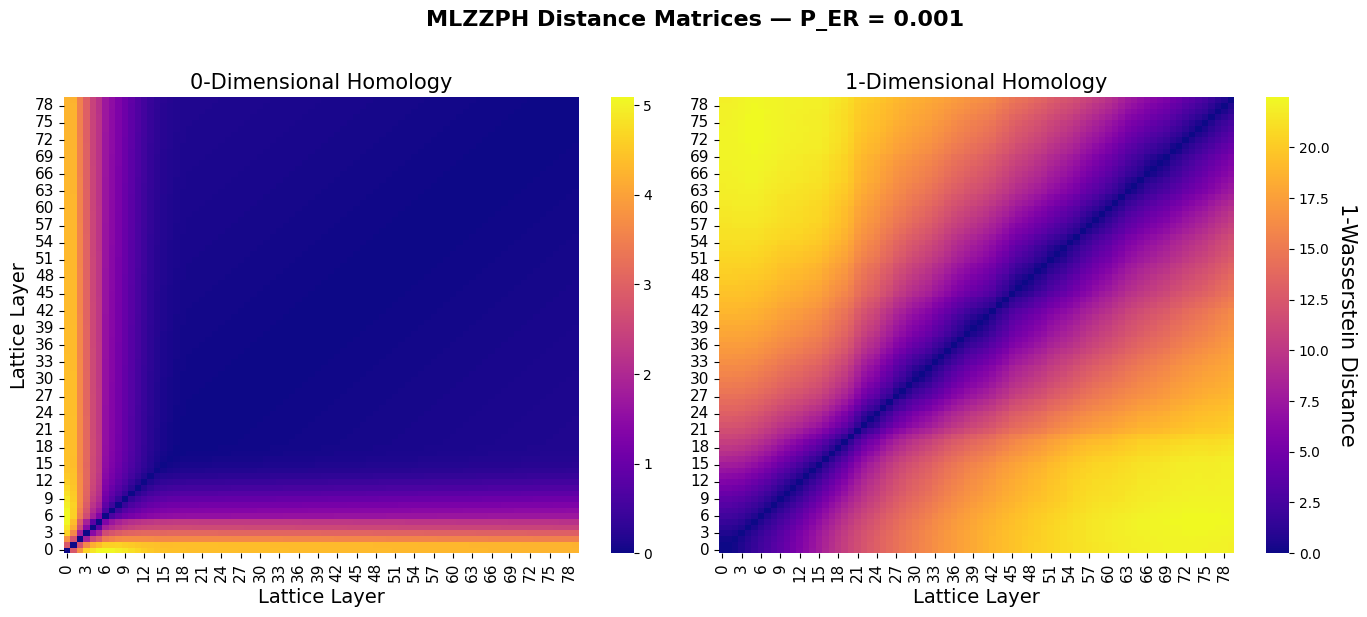

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 0.005:   0%|          | 0/8 [00:00<?, ?it/s]

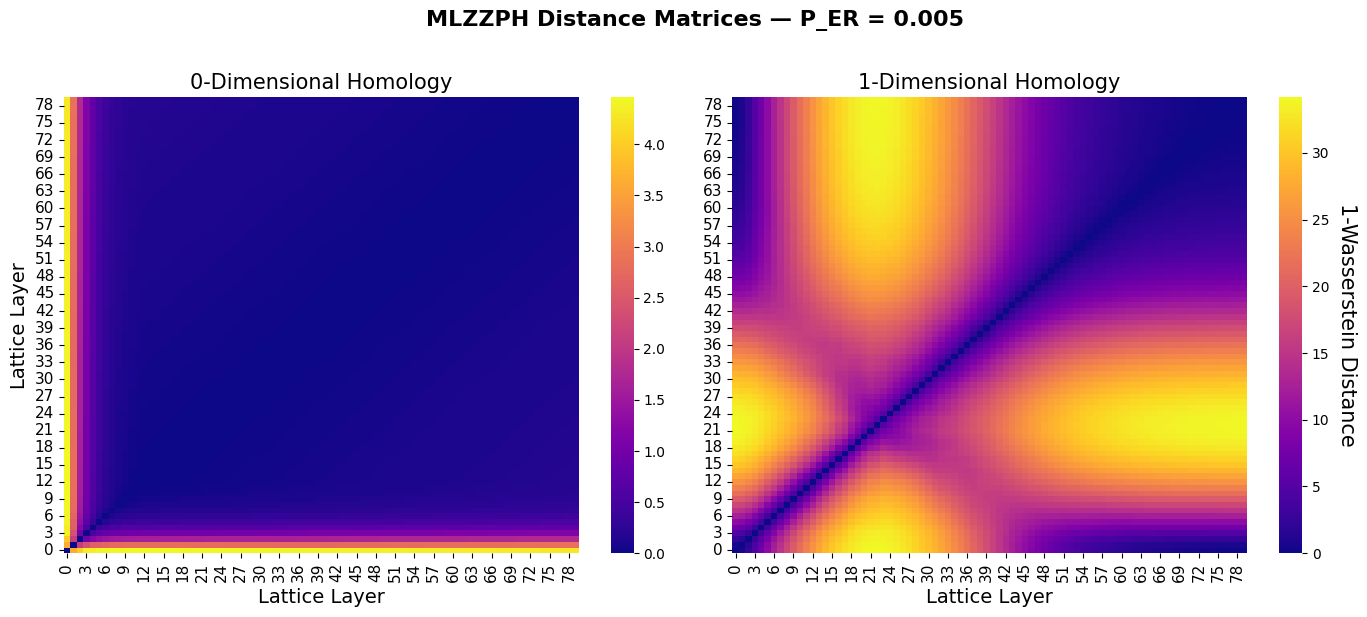

In [ ]:
N = 50; p_ER = [0.001,0.005]; max_P = 0.5; k_WS = 2; period = 40;
D0 = {p: dict() for p in p_ER}; D1 = {p: dict() for p in p_ER}; DGMs = {}
width = 1;

for p in tqdm(p_ER):
    length = 5 * period
    Edges = PeriodicRing(N, p, max_P, k_WS, period, length)
    DGMs[p] = []
    layers = range(2 * period)
    for layer in tqdm(layers):
        W = Windowing(width, layer, Edges)
        dgms = ZZPH(W, width, layer)
        DGMs[p].append(dgms)

    # Calculate 1-Wasserstein Distance
    d0, d1 = compute_distance_matrices(layers, p, DGMs, '1')
    D0[p]['1'] = d0
    D1[p]['1'] = d1

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))#, constrained_layout=True)
    fig.suptitle(f"MLZZPH Distance Matrices — P_ER = {p}",
             fontsize=16, fontweight="bold", y=1.02)
    sns.heatmap(d0, ax=ax[0], cmap="plasma")
    ax[0].set_title(f"0-Dimensional Homology",fontsize=15)
    ax[0].invert_yaxis()
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90, fontsize=11)
    ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=0, fontsize=11)
    ax[0].set_xlabel("Lattice Layer",fontsize=14)
    ax[0].set_ylabel("Lattice Layer",fontsize=14)

    sns.heatmap(d1, ax=ax[1], cmap="plasma",cbar_kws={"label": "1-Wasserstein Distance"})
    ax[1].set_title(f"1-Dimensional Homology",fontsize=15)
    ax[1].invert_yaxis()
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90, fontsize=11)
    ax[1].set_yticklabels(ax[0].get_yticklabels(), rotation=0, fontsize=11)
    ax[1].set_xlabel("Lattice Layer",fontsize=14)
    cbar = ax[1].collections[0].colorbar
    cbar.ax.set_ylabel("1-Wasserstein Distance", fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_period_group_publication_per(p_group, D0, D1, period, figsize=(10, 13)):
    nrows = len(p_group)

    # Collect matrices so each homology column uses a fixed shared color scale
    all_d0 = [np.asarray(D0[p]['1']) for p in p_group]
    all_d1 = [np.asarray(D1[p]['1']) for p in p_group]

    #vmin0 = min(arr.min() for arr in all_d0)
    #vmax0 = max(arr.max() for arr in all_d0)
    #vmin1 = min(arr.min() for arr in all_d1)
    #vmax1 = max(arr.max() for arr in all_d1)

    # Figure + axes
    fig, ax = plt.subplots(
        nrows, 2,
        figsize=figsize,
        constrained_layout=False,
        gridspec_kw={"wspace": 0.18, "hspace": 0.18}
    )

    if nrows == 1:
        ax = np.array([ax])

    # Supertitle
    fig.suptitle(
        f"Ring Model: Period = {period}, $p_{{\\max}}$ = {0.50}",
        fontsize=16,
        fontweight="bold",
        y=0.96
    )

    for i, p in enumerate(p_group):
        d0 = np.asarray(D0[p]['1'])
        d1 = np.asarray(D1[p]['1'])

        n0 = d0.shape[0]
        n1 = d1.shape[0]

        # Choose readable tick spacing automatically
        step0 = max(1, int(np.ceil(n0 / 10)))
        step1 = max(1, int(np.ceil(n1 / 10)))

        ticks0 = np.arange(0, n0, step0)
        ticks1 = np.arange(0, n1, step1)

        # ----- Left column: 0-dimensional homology -----
        hm0 = sns.heatmap(
            d0,
            ax=ax[i, 0],
            cmap="plasma",
            cbar=True,
            cbar_kws={"shrink": 1.0}
        )
        ax[i, 0].invert_yaxis()

        if i == 0:
            ax[i, 0].set_title("0-Dimensional Homology", fontsize=14, pad=6)

        if i == nrows - 1:
            ax[i, 0].set_xlabel("Lattice Layer", fontsize=12)
        else:
            ax[i, 0].set_xlabel("")

        ax[i, 0].set_ylabel("Lattice Layer", fontsize=12)

        ax[i, 0].set_xticks(ticks0 + 0.5)
        ax[i, 0].set_xticklabels(ticks0, rotation=90, fontsize=9)
        ax[i, 0].set_yticks(ticks0 + 0.5)
        ax[i, 0].set_yticklabels(ticks0, rotation=0, fontsize=9)

        # Remove label from left colorbar
        cbar0 = hm0.collections[0].colorbar
        cbar0.ax.set_ylabel("")
        cbar0.ax.tick_params(labelsize=10)

        # Horizontal period label with gray box behind it
        ax[i, 0].text(
            -0.25, 0.5,
            f"$p_{{random}}$ = {p}",
            transform=ax[i, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=12,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="lightgray",
                edgecolor="gray",
                alpha=1.0
            )
        )

        # ----- Right column: 1-dimensional homology -----
        hm1 = sns.heatmap(
            d1,
            ax=ax[i, 1],
            cmap="plasma",
            cbar=True,
            cbar_kws={"label": "1-Wasserstein Distance", "shrink": 1.0}
        )
        ax[i, 1].invert_yaxis()

        if i == 0:
            ax[i, 1].set_title("1-Dimensional Homology", fontsize=14, pad=6)

        if i == nrows - 1:
            ax[i, 1].set_xlabel("Lattice Layer", fontsize=12)
        else:
            ax[i, 1].set_xlabel("")

        ax[i, 1].set_ylabel("")

        ax[i, 1].set_xticks(ticks1 + 0.5)
        ax[i, 1].set_xticklabels(ticks1, rotation=90, fontsize=9)
        ax[i, 1].set_yticks(ticks1 + 0.5)
        ax[i, 1].set_yticklabels(ticks1, rotation=0, fontsize=9)

        cbar1 = hm1.collections[0].colorbar
        cbar1.ax.set_ylabel("1-Wasserstein Distance", fontsize=12, rotation=270, labelpad=16)
        cbar1.ax.tick_params(labelsize=10)

    plt.tight_layout(rect=[0.10, 0.04, 0.98, 0.91])
    plt.show()

/tmp/ipykernel_57583/3122021530.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.10, 0.04, 0.98, 0.91])


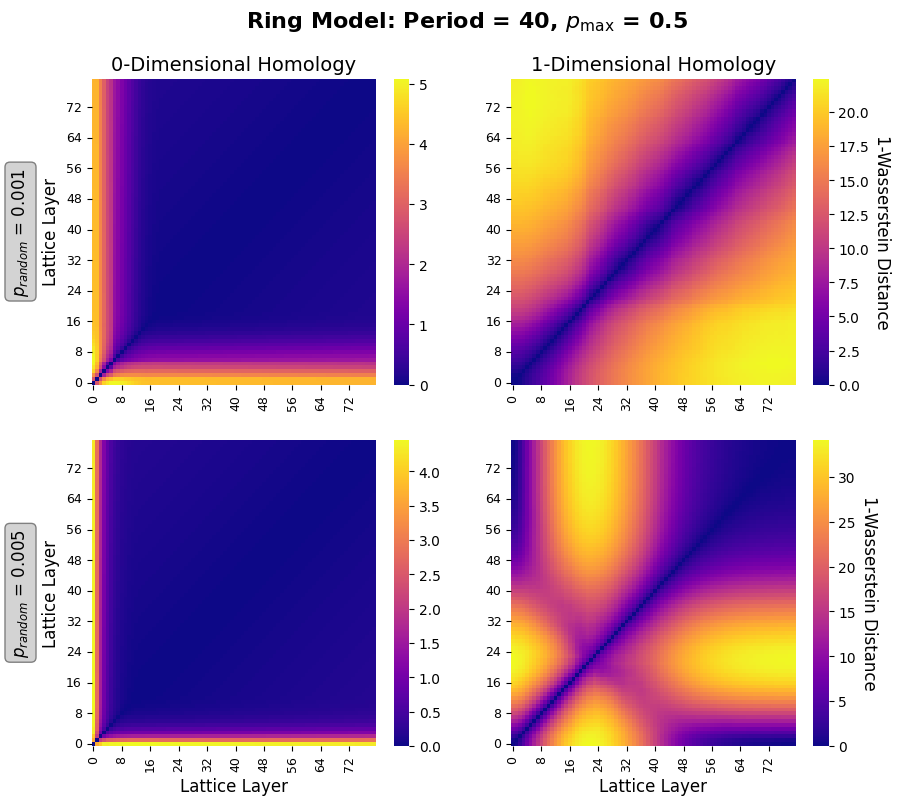

In [ ]:
plot_period_group_publication_per([0.001,0.005], D0, D1, 40, figsize=(10, 13*2/3))

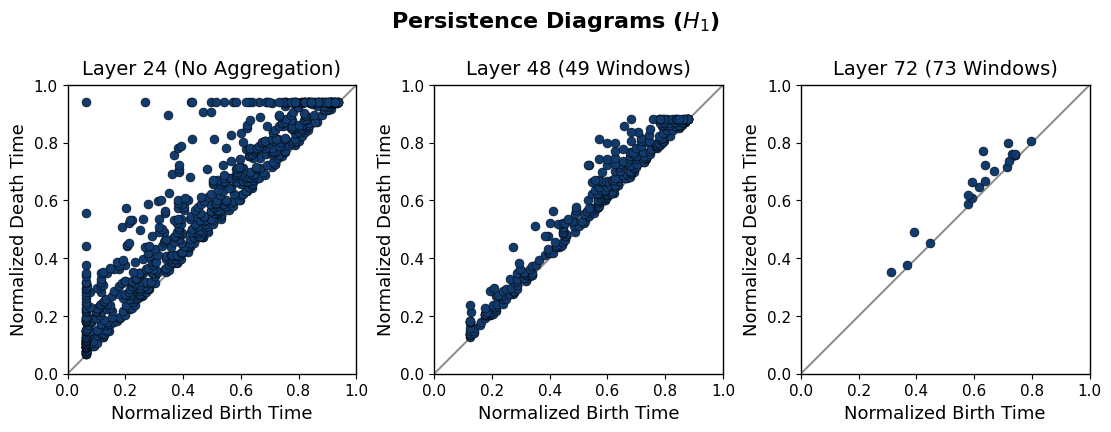

In [ ]:
# Example usage for your four diagrams
layer1 = 24
layer2 = 48
layer3 = 72
period = 0.005

# ---- H1 figure ----
fig, ax = plt.subplots(1, 3, figsize=(11, 5.5), constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[period][layer1][1],
    ax=ax[0],
    title=f"Layer {layer1} (No Aggregation)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer2][1],
    ax=ax[1],
    title=f"Layer {layer2} ({layer2+1} Windows)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer3][1],
    ax=ax[2],
    title=f"Layer {layer3} ({layer3+1} Windows)"
)

fig.suptitle(f"Persistence Diagrams ($H_1$)", fontsize=16, fontweight="bold", y = 0.9)
plt.show()

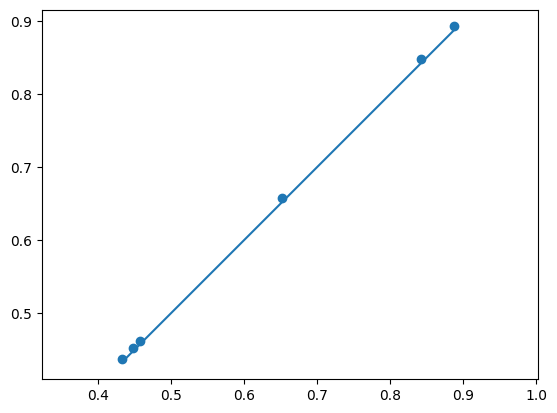

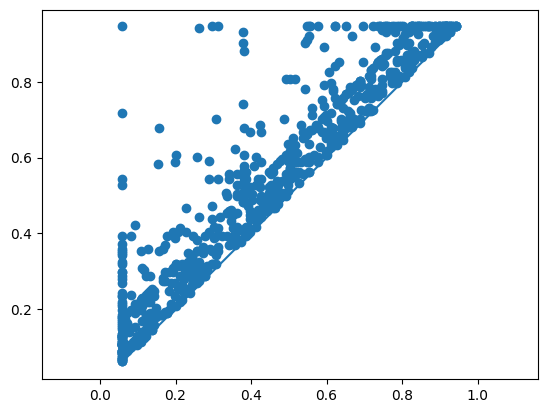

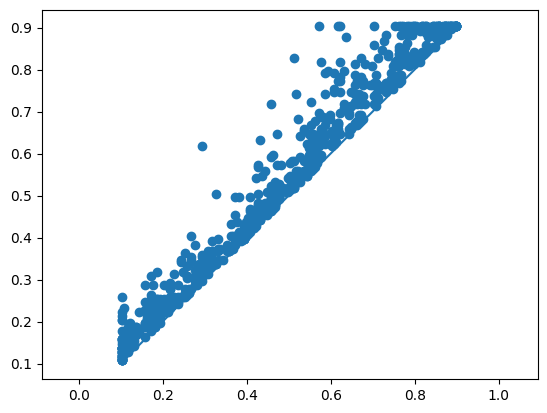

In [ ]:
layer1 = 0; layer2 = 22; layer3 = 40; p = 0.005
d.plot.plot_diagram(DGMs[p][layer1][1], show = True)
d.plot.plot_diagram(DGMs[p][layer2][1], show = True)
d.plot.plot_diagram(DGMs[p][layer3][1], show = True)